# Scenario 01 - Doctor Chat Over A Long Cancer Handbook

This notebook is a Tensormesh customer demo.

Customer story:
- The customer is a doctor.
- The doctor has a long cancer handbook in `docs/cancer_disease_handbook.md`.
- The doctor asks multiple follow-up questions against that same long handbook.

What this demo is meant to show:
- The first request is the cold request and pays the full long-prefix setup cost.
- Later requests reuse the same long shared prefix.
- On Tensormesh, those later chats should usually show lower TTFT because the KV cache can reuse that shared prefix.

How the notebook is built:
1. Load the long cancer handbook from `docs/`.
2. Create one session hash for this demo run so the prefix is isolated from previous notebook runs.
3. Build one shared system prompt: `session_hash + handbook + fixed doctor-facing instructions`.
4. Send several different doctor questions, all using that same shared system prompt.
5. Measure TTFT only and compare the cold request with the warm follow-up requests.


## Setup And Run

Scenario folder contents:
- `scenario_01_long_document_chat.ipynb`
- `docs/cancer_disease_handbook.md`

Required environment variables:
- `OPENAI_BASE_URL`
- `OPENAI_API_KEY`
- `TENSORMESH_USER_ID`
- `OPENAI_MODEL`

Expected repo setup:
- Create `.env` from `.env.example` at the repo root.
- Install dependencies from `requirements.txt`.

Interactive run:
```bash
python3 -m jupyter notebook scenarios/01_long_document_chat/scenario_01_long_document_chat.ipynb
```

Headless run:
```bash
python3 -m nbconvert --to notebook --execute --inplace scenarios/01_long_document_chat/scenario_01_long_document_chat.ipynb --ExecutePreprocessor.timeout=900
```

Measurement rule:
- TTFT is measured at the first non-empty streamed token, not the first empty frame.
- For reasoning-capable models, that first token may be a reasoning token.
- The notebook stops reading each stream as soon as that first non-empty token arrives, so the demo measures TTFT only and does not wait for full answers.

Fixed notebook settings:
- `MAX_TOKENS = 32`
- `TEMPERATURE = 0.0`
- `REQUEST_TIMEOUT_S = 30.0`
- `DOCTOR_QUESTIONS = 10` (`1` cold + `9` warm)

How to interpret results:
- `run_1_cold` is the first chat over the long handbook.
- `run_2_warm` and later runs are follow-up chats over the same long shared prefix.
- The strongest demo outcome is that the warm median TTFT is lower than the cold TTFT.
- If one warm request is slower, that usually means endpoint noise or queueing, not that the shared-prefix design changed.

Troubleshooting:
- If `nbconvert` appears to pause after `Converting notebook ...`, that is normal while the benchmark cell is waiting on remote streamed requests.
- This notebook closes each stream right after TTFT is captured, so it should finish much faster than a full-answer benchmark.
- If you get `503`, the deployed model is temporarily unavailable.
- If you get `404`, `OPENAI_MODEL` does not match a model served by the endpoint.


In [1]:
from pathlib import Path
import os
import time
import uuid
from statistics import median
from typing import Any
import matplotlib.pyplot as plt
from openai import OpenAI


def locate_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scenarios/01_long_document_chat').exists():
            return candidate
    raise RuntimeError(
        'Could not locate the repository root from the current working directory.'
    )


REPO_ROOT = locate_repo_root(Path.cwd())
SCENARIO_DIR = REPO_ROOT / 'scenarios/01_long_document_chat'
DOCUMENT_PATH = SCENARIO_DIR / 'docs/cancer_disease_handbook.md'

MAX_TOKENS = 32
TEMPERATURE = 0.0
REQUEST_TIMEOUT_S = 30.0
DOCTOR_QUESTIONS = [
    ('run_1_cold',
     'A patient asks for the most important modifiable cancer risk factors. Give a concise doctor-facing counseling summary.'
     ),
    ('run_2_warm',
     'What screening areas are commonly discussed in this handbook, and what is the handbook\'s caution about screening tradeoffs?'
     ),
    ('run_3_warm',
     'List the general warning symptoms that should trigger medical evaluation, using only the handbook.'
     ),
    ('run_4_warm',
     'Summarize the high-level staging factors a doctor should review before discussing treatment options.'
     ),
    ('run_5_warm',
     'Give a short prevention counseling checklist for a primary-care follow-up visit, using only this handbook.'
     ),
    ('run_6_warm',
     'Explain the handbook\'s high-level view of how surgery, radiation, and systemic therapy fit into treatment planning.'
     ),
    ('run_7_warm',
     'What does the handbook emphasize about survivorship follow-up and monitoring after treatment?'
     ),
    ('run_8_warm',
     'Summarize the handbook\'s supportive-care and symptom-management priorities for complex cancer cases.'
     ),
    ('run_9_warm',
     'Which findings in the handbook suggest urgent escalation or specialist referral rather than routine follow-up?'
     ),
    ('run_10_warm',
     'Give a concise doctor-facing checklist for discussing prognosis, uncertainty, and shared decision-making with patients.'
     ),
]


def load_dotenv(dotenv_path: Path) -> None:
    if not dotenv_path.exists():
        return
    for raw_line in dotenv_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        os.environ.setdefault(key, value)


def require_env(name: str) -> str:
    value = os.environ.get(name)
    if not value:
        raise RuntimeError(f'Missing required environment variable: {name}')
    return value


def mask_secret(value: str, keep: int = 4) -> str:
    if len(value) <= keep * 2:
        return '*' * len(value)
    return f"{value[:keep]}...{value[-keep:]}"


load_dotenv(REPO_ROOT / '.env')

In [2]:
base_url = require_env('OPENAI_BASE_URL').rstrip('/')
api_key = require_env('OPENAI_API_KEY')
user_id = require_env('TENSORMESH_USER_ID')
model = require_env('OPENAI_MODEL')

if not DOCUMENT_PATH.exists():
    raise FileNotFoundError(f'Missing document: {DOCUMENT_PATH}')

document_text = DOCUMENT_PATH.read_text(encoding='utf-8').strip()
session_hash = uuid.uuid4().hex[:12]
shared_system_prompt = '\n\n'.join([
    f'DEMO_SESSION_HASH={session_hash}',
    'ROLE: You are assisting a doctor who is reviewing a long cancer handbook.',
    'RULE: Use only the handbook content below. If the handbook does not support a claim, say "not stated in handbook".',
    'STYLE: Respond in concise doctor-facing bullets.',
    'HANDBOOK',
    document_text,
])

print('Configuration')
print(f'  OPENAI_BASE_URL      : {base_url}')
print(f'  OPENAI_MODEL         : {model}')
print(f'  TENSORMESH_USER_ID   : {user_id}')
print(f'  OPENAI_API_KEY       : {mask_secret(api_key)}')
print(f'  document_path        : {DOCUMENT_PATH.relative_to(REPO_ROOT)}')
print(f'  document_characters  : {len(document_text):,}')
print(f'  session_hash         : {session_hash}')
print(f'  doctor_questions     : {len(DOCTOR_QUESTIONS)}')

Configuration
  OPENAI_BASE_URL      : https://external.nebius.tensormesh.ai/v1
  OPENAI_MODEL         : openai/gpt-oss-20b
  TENSORMESH_USER_ID   : 60b01a41-c8a4-4234-80a5-ef18309b560c
  OPENAI_API_KEY       : ak-4...fdMX
  document_path        : scenarios/01_long_document_chat/docs/cancer_disease_handbook.md
  document_characters  : 40,446
  session_hash         : 454952ae418d
  doctor_questions     : 10


In [3]:
client = OpenAI(
    api_key=api_key,
    base_url=base_url,
    default_headers={'X-User-Id': user_id},
)


def normalize_obj(value: Any) -> Any:
    if value is None:
        return None
    if hasattr(value, 'model_dump'):
        return value.model_dump(exclude_none=True)
    if isinstance(value, dict):
        return {key: normalize_obj(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [normalize_obj(item) for item in value]
    return value


def iter_text_fragments(value: Any):
    normalized = normalize_obj(value)
    if normalized is None:
        return
    if isinstance(normalized, str):
        if normalized.strip():
            yield normalized
        return
    if isinstance(normalized, dict):
        for key, item in normalized.items():
            if key in {'role', 'type', 'index', 'finish_reason', 'logprobs'}:
                continue
            yield from iter_text_fragments(item)
        return
    if isinstance(normalized, list):
        for item in normalized:
            yield from iter_text_fragments(item)


def extract_text_fragments(chunk: Any) -> list[str]:
    choices = getattr(chunk, 'choices', None)
    if choices is None:
        chunk_data = normalize_obj(chunk)
        choices = chunk_data.get('choices', []) if isinstance(
            chunk_data, dict) else []
    fragments: list[str] = []
    for choice in choices or []:
        delta = getattr(choice, 'delta', None)
        if delta is None and isinstance(choice, dict):
            delta = choice.get('delta')
        fragments.extend(iter_text_fragments(delta))
    return fragments


def run_doctor_question(question_label: str,
                        question_text: str) -> dict[str, Any]:
    started_at = time.perf_counter()
    first_token_ms = None
    first_fragments: list[str] = []
    messages = [
        {
            'role': 'system',
            'content': shared_system_prompt
        },
        {
            'role': 'user',
            'content': question_text
        },
    ]
    stream = client.chat.completions.create(
        model=model,
        messages=messages,
        max_tokens=MAX_TOKENS,
        temperature=TEMPERATURE,
        stream=True,
        timeout=REQUEST_TIMEOUT_S,
    )
    try:
        for chunk in stream:
            fragments = extract_text_fragments(chunk)
            if not fragments:
                continue
            first_token_ms = (time.perf_counter() - started_at) * 1000
            first_fragments.extend(fragments)
            break
    finally:
        close = getattr(stream, 'close', None)
        if callable(close):
            close()
    if first_token_ms is None:
        raise RuntimeError(
            'The stream ended before a non-empty token was emitted.')
    return {
        'run_label': question_label,
        'question': question_text,
        'ttft_ms': first_token_ms,
        'first_fragment': ''.join(first_fragments)[:120],
    }

In [4]:
records: list[dict[str, Any]] = []

print('Running one doctor chat session over a shared long-prefix handbook')
for question_label, question_text in DOCTOR_QUESTIONS:
    result = run_doctor_question(question_label, question_text)
    records.append(result)
    print(f"  {question_label}: TTFT={result['ttft_ms']:.1f} ms")

Running one doctor chat session over a shared long-prefix handbook


  run_1_cold: TTFT=2178.2 ms


  run_2_warm: TTFT=2143.7 ms


  run_3_warm: TTFT=2468.7 ms


  run_4_warm: TTFT=2387.5 ms


...

  run_6_warm: TTFT=1855.1 ms


  run_7_warm: TTFT=1651.6 ms


  run_8_warm: TTFT=1715.9 ms


  run_9_warm: TTFT=1639.8 ms


  run_10_warm: TTFT=1232.4 ms


In [5]:
ttfts = [row['ttft_ms'] for row in records]
cold_ttft_ms = ttfts[0]
warm_ttfts = ttfts[1:]
warm_median_ttft_ms = median(warm_ttfts)
warm_best_ttft_ms = min(warm_ttfts)
all_warm_faster = all(value < cold_ttft_ms for value in warm_ttfts)
warm_median_faster = warm_median_ttft_ms < cold_ttft_ms
observed_speedup = cold_ttft_ms / warm_median_ttft_ms if warm_median_ttft_ms else float(
    'inf')

print('Demo summary')
print(f'  cold_ttft_ms        : {cold_ttft_ms:.1f}')
print(f'  warm_median_ttft_ms : {warm_median_ttft_ms:.1f}')
print(f'  warm_best_ttft_ms   : {warm_best_ttft_ms:.1f}')
print(f'  cold_to_warm_ratio  : {observed_speedup:.2f}x')
print(f'  all_warm_faster     : {all_warm_faster}')
if all_warm_faster:
    print(
        '  demo_result         : every warm follow-up chat was faster than the cold first chat'
    )
    print(
        '  tensormesh_story    : the long shared prefix was reused after the first request'
    )
elif warm_median_faster:
    print(
        '  demo_result         : warm follow-up chats were faster on median, but one warm run was noisy'
    )
    print(
        '  tensormesh_story    : the long shared prefix still showed a clear warm-up effect overall'
    )
else:
    print(
        '  demo_result         : this run was noisy and did not show a faster warm median'
    )
    print(
        '  tensormesh_story    : rerun under lighter load to show the shared-prefix reuse pattern more clearly'
    )

Demo summary
  cold_ttft_ms        : 2178.2
  warm_median_ttft_ms : 1715.9
  warm_best_ttft_ms   : 1232.4
  cold_to_warm_ratio  : 1.27x
  all_warm_faster     : False
  demo_result         : warm follow-up chats were faster on median, but one warm run was noisy
  tensormesh_story    : the long shared prefix still showed a clear warm-up effect overall


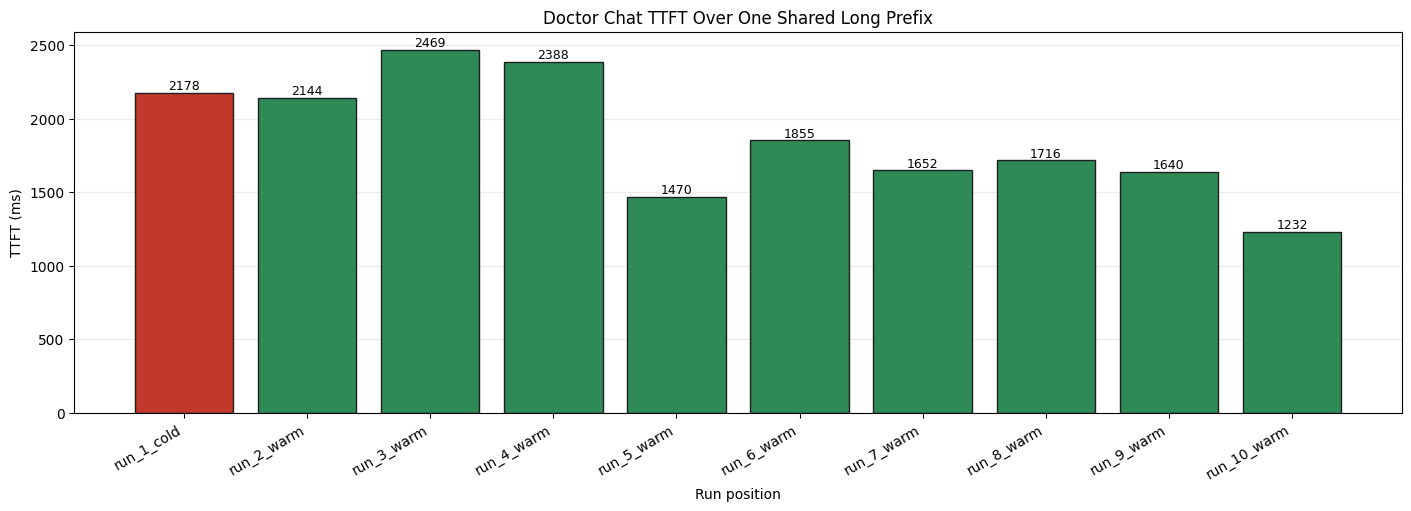

In [6]:
labels = [row['run_label'] for row in records]
ttfts = [row['ttft_ms'] for row in records]
colors = ['#c0392b'] + ['#2e8b57'] * (len(records) - 1)

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
bars = ax.bar(labels, ttfts, color=colors, edgecolor='#1f1f1f')
ax.set_title('Doctor Chat TTFT Over One Shared Long Prefix')
ax.set_xlabel('Run position')
ax.set_ylabel('TTFT (ms)')
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

for bar, value in zip(bars, ttfts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.show()